# SS2P2 on a toy temporal point process

**Goal.** Illustrate, end to end, how the SS2P2 model in this repo trains and where
$\lambda(t)$ (total intensity) and $p(k\,|\,t)$ (mark distribution) come from —
on a process small enough to see everything.

The model factorizes a marked temporal point process as

$$\lambda_k(t) \;=\; \underbrace{\lambda(t)}_{\text{bounded rate head}} \times \underbrace{p(k\,|\,t)}_{\text{rate-neutral softmax head}}, \qquad \sum_k \lambda_k(t) = \lambda(t),$$

and trains by maximizing the next-event log-likelihood over sliding windows:

$$\log \mathcal{L} \;=\; \underbrace{\log \lambda(t_{\text{next}}) - \int_{t_{\text{last}}}^{t_{\text{next}}} \lambda(s)\,ds}_{\text{timing (when)}} \;+\; \underbrace{\log p(k_{\text{next}}\,|\,t_{\text{next}})}_{\text{mark (what)}}.$$

We generate data from a **bivariate Hawkes process** with known ground truth, train a tiny
SS2P2 (`decoder_type='ss2p2'`, the exact classes used in the paper), and compare the learned
$\hat\lambda(t)$ and $\hat p(k|t)$ against the true ones.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath('..'))   # repo root

import numpy as np
import torch
import matplotlib.pyplot as plt

torch.manual_seed(0); np.random.seed(0)
plt.rcParams.update({'figure.dpi': 110, 'font.size': 9})
device = torch.device('cpu')

## 1. Ground truth: a bivariate Hawkes process

Two event types with exponential kernels:

$$\lambda^{\text{true}}_k(t) = \mu_k + \sum_{j\in\{0,1\}} \alpha_{kj} \sum_{t_i^{(j)} < t} \beta\, e^{-\beta (t - t_i^{(j)})}$$

Type **1** is the "aggressor": it strongly excites both types (bursts). Type **0** has the
higher base rate (calm background). So the *true* mark distribution
$p^{\text{true}}(k|t) = \lambda^{\text{true}}_k(t)/\lambda^{\text{true}}(t)$ swings toward
type 1 inside bursts — exactly the structure the two heads must separately recover.
We simulate by Ogata thinning.

In [2]:
MU    = np.array([0.35, 0.03])            # base rates (ev/s): calm = mostly type 0
ALPHA = np.array([[0.05, 0.55],           # alpha[k, j]: j excites k
                  [0.02, 0.55]])          # type 1 -> strong self+cross excitation
BETA  = 1.5                               # kernel decay (1/s)
T_END = 6000.0

def true_intensity(t, ev_t, ev_k):
    # lambda^true_k(t) given events strictly before t
    lam = MU.copy()
    past = ev_t < t
    for j in (0, 1):
        s = np.sum(BETA * np.exp(-BETA * (t - ev_t[past & (ev_k == j)])))
        lam += ALPHA[:, j] * s
    return lam

# Ogata thinning
ev_t, ev_k = [], []
t, lam_bar = 0.0, MU.sum() + 20.0
while t < T_END:
    t += np.random.exponential(1.0 / lam_bar)
    lam = true_intensity(t, np.array(ev_t), np.array(ev_k))
    if np.random.rand() < lam.sum() / lam_bar:
        ev_k.append(np.random.choice(2, p=lam / lam.sum()))
        ev_t.append(t)
ev_t, ev_k = np.array(ev_t), np.array(ev_k)
print(f"{len(ev_t)} events over {T_END:.0f}s "
      f"(rate {len(ev_t)/T_END:.2f} ev/s; type shares {np.bincount(ev_k)/len(ev_k)})")

# branching ratio (spectral radius of the alpha matrix) -- subcritical
print("spectral radius of ALPHA:", round(np.max(np.abs(np.linalg.eigvals(ALPHA))), 3))

3006 events over 6000s (rate 0.50 ev/s; type shares [0.83067199 0.16932801])
spectral radius of ALPHA: 0.571


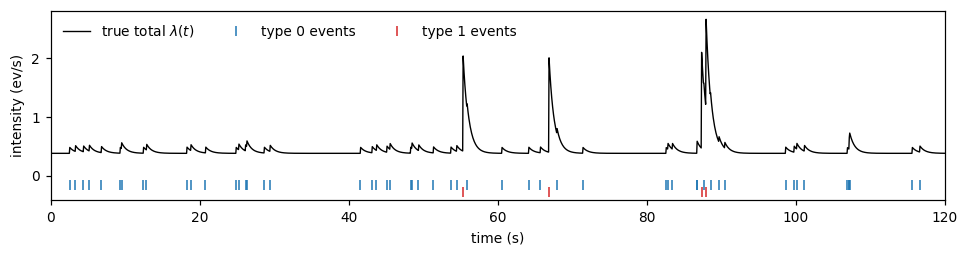

In [3]:
fig, ax = plt.subplots(figsize=(9, 2.4))
grid = np.linspace(0, 120, 2000)
lam_true = np.array([true_intensity(t, ev_t, ev_k) for t in grid])
ax.plot(grid, lam_true.sum(1), 'k', lw=0.9, label=r'true total $\lambda(t)$')
for k, c in [(0, 'tab:blue'), (1, 'tab:red')]:
    m = (ev_k == k) & (ev_t < 120)
    ax.plot(ev_t[m], np.full(m.sum(), -0.15 - 0.12*k), '|', color=c, ms=7,
            label=f'type {k} events')
ax.set(xlabel='time (s)', ylabel='intensity (ev/s)', xlim=(0, 120))
ax.legend(ncol=3, frameon=False); plt.tight_layout()

## 2. Windowed training samples

The repo trains on a **windowed next-event objective** (`VolumeSetMTPP.compute_loss`,
`volume_set_mtpp.py:460`): each sample is a context window of `SEQ` events
(`input_times` = inter-event deltas $\Delta t_i$, `input_marks` = one-hot types) and the
**next** event as the target (`target_time` = delta from the last context event,
`target_marks` = its one-hot type). This mirrors the LOB pipeline exactly, just with
$K=2$ instead of 62 channels.

In [4]:
SEQ = 64
dts   = np.diff(ev_t, prepend=0.0).astype(np.float32)
marks = np.eye(2, dtype=np.float32)[ev_k]

def make_batch(idx):
    # sample windows ending at positions idx (target = event at idx)
    return {'input_times':  torch.tensor(np.stack([dts[i-SEQ:i]   for i in idx])),
            'input_marks':  torch.tensor(np.stack([marks[i-SEQ:i] for i in idx])),
            'target_time':  torch.tensor(dts[idx]),
            'target_marks': torch.tensor(marks[idx])}

train_idx = np.arange(SEQ, int(0.8 * len(ev_t)))       # 80/20 time split
test_idx  = np.arange(int(0.8 * len(ev_t)) + SEQ, len(ev_t))
print(f"{len(train_idx)} train windows, {len(test_idx)} test windows")

2340 train windows, 538 test windows


## 3. Build the actual SS2P2 model

`create_volume_set_mtpp` (`volume_set_mtpp.py:807`) with `decoder_type='ss2p2'` wires
`SS2P2SetDecoder` (`ss2p2_decoder.py:46`) — the S2P2 state-space backbone with the two
decoupled heads:

- **rate head** `ground_intensity(u)`: $\lambda = s\cdot\mathrm{softplus}\!\big(c - \mathrm{softplus}(c - w^\top(\sigma(W_o u)\odot\tanh u))\big)$ — hard closed-form ceiling $\lambda \le s\cdot\mathrm{softplus}(c)$, floor exactly 0;
- **mark head** `mark_score(u)`: $p(k|t) = \mathrm{softmax}(\mathrm{MLP}(u))$ — cannot move the total rate.

`mark_head='categorical'` selects softmax cross-entropy for the mark term (one type per event).

In [5]:
from volume_set_mtpp.models.volume_set_mtpp import create_volume_set_mtpp

config = {
    'decoder_type': 'ss2p2',
    'channel_embedding_size': 8,
    'time_embedding_size': 8,
    'recurrent_hidden_size': 32,
    's2p2_layers': 2,
    'target_rate': len(ev_t) / T_END,   # initialize the rate scale near the data rate
    'ss2p2_wnorm_cap': 6.0,             # the z-ceiling c
    'mark_head': 'categorical',
}
model = create_volume_set_mtpp(num_channels=2, config=config, device=device, use_volume=False)
lo, hi = model.decoder.rate_bounds()
print(f"parameters: {sum(p.numel() for p in model.parameters()):,}")
print(f"closed-form rate ceiling at init: lambda <= {hi:.1f} ev/s (floor {lo:.3f})")

parameters: 9,335
closed-form rate ceiling at init: lambda <= 4.3 ev/s (floor 0.000)


## 4. Train

`model.compute_loss(batch)` returns the negative log-likelihood
(timing NLL + mark cross-entropy) plus a metrics dict — the same call the real
training loop makes (`training/train.py:96`).

step    0  loss 146.977   time_nll 110.435   mark  1.225


step  500  loss  77.007   time_nll  52.799   mark  0.940


step 1000  loss  69.475   time_nll  52.578   mark  0.777


step 1500  loss  66.843   time_nll  53.585   mark  0.730


step 2000  loss  60.771   time_nll  49.362   mark  0.671


step 2500  loss  60.130   time_nll  50.859   mark  0.725


step 2999  loss  59.586   time_nll  51.203   mark  0.664


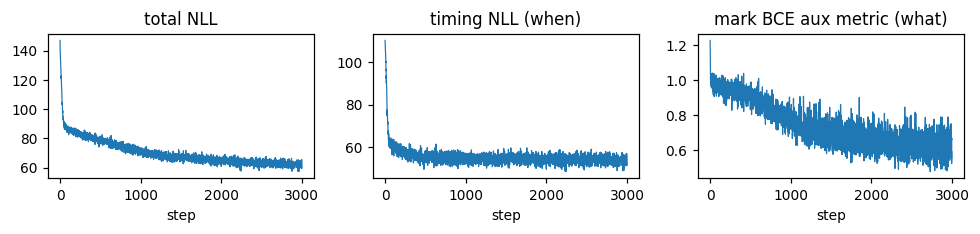

In [6]:
opt = torch.optim.Adam(model.parameters(), lr=3e-3, weight_decay=1e-4)
sched = torch.optim.lr_scheduler.StepLR(opt, step_size=1200, gamma=0.3)
hist = {'loss': [], 'time_nll': [], 'mark': []}
STEPS, BATCH = 3000, 128

model.train()
for step in range(STEPS):
    batch = make_batch(np.random.choice(train_idx, BATCH))
    loss, metrics = model.compute_loss(batch, device)
    opt.zero_grad(); loss.backward()
    torch.nn.utils.clip_grad_norm_(model.parameters(), 5.0)
    opt.step(); sched.step()
    hist['loss'].append(float(loss))
    hist['time_nll'].append(metrics.get('time_nll', float('nan')))
    hist['mark'].append(metrics.get('mark_ce', metrics.get('mark_bce', float('nan'))))
    if step % 500 == 0 or step == STEPS - 1:
        print(f"step {step:4d}  loss {float(loss):7.3f}   "
              f"time_nll {hist['time_nll'][-1]:7.3f}   mark {hist['mark'][-1]:6.3f}")

fig, axes = plt.subplots(1, 3, figsize=(9, 2.2))
for ax, key, ttl in zip(axes, ['loss', 'time_nll', 'mark'],
                        ['total NLL', 'timing NLL (when)', 'mark BCE aux metric (what)']):
    ax.plot(hist[key], lw=0.8); ax.set_title(ttl); ax.set_xlabel('step')
plt.tight_layout()

## 4b. The loss, by hand, on 10 events

Same formula, but small enough to *see every number*. We take one held-out window of
$W{=}10$ events plus its target and reproduce `compute_loss` term by term
(`volume_set_mtpp.py:552-670`, endpoint survival rule):

- $\lambda(t_i^-)$ — total intensity just **before** each event (left-limit states: an
  event never informs its own intensity);
- $\log\lambda(t_i^-)$ — the positive timing reward for each observed event;
- $\lambda(t_i^-)\,\Delta t_i$ — that interval's slice of the compensator
  $\int\lambda$ (the "cost of predicting rate even when nothing happens");
- $p(k_i|t_i)$, $\log p$ — the mark head's probability of the type that actually occurred.

In [7]:
W = 10
i_tgt = int(test_idx[5])                     # a held-out target event
sl = slice(i_tgt - W, i_tgt)
b10 = {'input_times':  torch.tensor(dts[sl][None]),
       'input_marks':  torch.tensor(marks[sl][None]),
       'target_time':  torch.tensor(dts[i_tgt:i_tgt+1]),
       'target_marks': torch.tensor(marks[i_tgt:i_tgt+1])}

model.eval()
with torch.no_grad():
    ts = torch.cumsum(b10['input_times'], dim=1)
    # right-limit states (for queries after events) + event LEFT-limit states
    states, event_states = model.decoder.get_states_and_event_left_states(
        marks=b10['input_marks'], timestamps=ts)
    d_ev = model.get_total_intensity_and_items(event_states)
    lam_ev = d_ev['total_intensity'][0, :, 0]            # lambda(t_i^-)
    p_ev   = d_ev['item_probability'][0]                 # p(k | t_i)
    # target: evolve the state to t_last + target_dt, same as evaluation
    t_q = ts[:, -1:] + b10['target_time'].unsqueeze(1)
    h_tg = model.decoder.get_hidden_h(state_values=states, state_times=ts, timestamps=t_q)
    d_tg = model.get_total_intensity_and_items(h_tg)
    lam_tg = float(d_tg['total_intensity'][0, 0, 0])
    p_tg   = d_tg['item_probability'][0, 0]

k_true = b10['input_marks'][0].argmax(-1)
kt     = int(b10['target_marks'][0].argmax())
hdr = f"{'i':>3} {'dt_i(s)':>8} {'type':>4} {'lam(ti-)':>9} {'log lam':>8} {'lam*dt':>7} {'p(k|t)':>7} {'log p':>7}"
print(hdr); print('-' * len(hdr))
for i in range(W):
    lam, dt_i = float(lam_ev[i]), float(b10['input_times'][0, i])
    pk = float(p_ev[i, k_true[i]])
    print(f"{i:>3} {dt_i:>8.3f} {int(k_true[i]):>4} {lam:>9.3f} {np.log(lam):>8.3f} "
          f"{lam*dt_i:>7.3f} {pk:>7.3f} {np.log(pk):>7.3f}")
pkt = float(p_tg[kt])
print(f"{'tgt':>3} {float(b10['target_time'][0]):>8.3f} {kt:>4} {lam_tg:>9.3f} "
      f"{np.log(lam_tg):>8.3f} {lam_tg*float(b10['target_time'][0]):>7.3f} {pkt:>7.3f} {np.log(pkt):>7.3f}")

  i  dt_i(s) type  lam(ti-)  log lam  lam*dt  p(k|t)   log p
------------------------------------------------------------
  0    0.082    0    10.603    2.361   0.874   0.695  -0.363
  1    0.637    1     1.725    0.545   1.098   0.048  -3.028
  2    0.132    1     7.784    2.052   1.028   0.008  -4.807
  3    0.101    0     9.437    2.245   0.951   0.548  -0.601
  4    0.073    0    13.155    2.577   0.958   0.059  -2.823
  5    0.099    1    11.280    2.423   1.119   0.797  -0.227
  6    0.133    1     6.276    1.837   0.835   0.071  -2.648
  7    0.049    1    10.847    2.384   0.535   0.208  -1.572
  8    0.307    0     3.896    1.360   1.195   0.012  -4.434
  9    0.197    0     4.941    1.598   0.974   0.984  -0.017
tgt    0.236    1     4.189    1.432   0.988   0.087  -2.442


In [8]:
# assemble exactly as compute_loss does (endpoint survival rule)
log_lam_sum = float(torch.log(lam_ev + 1e-8).sum())        # sum_i log lambda(t_i^-)
log_lam_tgt = float(np.log(lam_tg + 1e-8))                 # log lambda(t_target)
surv        = float((b10['input_times'][0] * lam_ev).sum()) \
            + lam_tg * float(b10['target_time'][0])         # ~ integral of lambda ds
logp_sum    = float(torch.log(p_ev[torch.arange(W), k_true]).sum())
logp_tgt    = float(np.log(pkt))

time_nll = -(log_lam_sum + log_lam_tgt) + surv             # "when"
mark_nll = -(logp_sum + logp_tgt)                          # "what"

print(f"timing:  -(sum log lam = {log_lam_sum:8.3f})  -(log lam_tgt = {log_lam_tgt:6.3f})"
      f"  + (survival = {surv:6.3f})   -> time NLL = {time_nll:8.3f}")
print(f"marks:   -(sum log p   = {logp_sum:8.3f})  -(log p_tgt   = {logp_tgt:6.3f})"
      f"                          -> mark NLL = {mark_nll:8.3f}")
print(f"hand total NLL      = {time_nll + mark_nll:.4f}")

loss, metrics = model.compute_loss(b10, device)
print(f"model.compute_loss  = {float(loss):.4f}   (time_nll {metrics['time_nll']:.4f})")

timing:  -(sum log lam =   19.381)  -(log lam_tgt =  1.432)  + (survival = 10.556)   -> time NLL =  -10.257
marks:   -(sum log p   =  -20.521)  -(log p_tgt   = -2.442)                          -> mark NLL =   22.962
hand total NLL      = 12.7054
model.compute_loss  = 12.7054   (time_nll -10.2570)


**How to read the table.** Rows with a *short* gap after a burst show high
$\lambda(t_i^-)$ — the timing term rewards that with a large $\log\lambda$; rows with a
*long* quiet gap contribute little $\log\lambda$ but a large $\lambda\cdot\Delta t$
compensator cost, which is what pushes $\hat\lambda$ down in calm stretches. The mark
column is independent bookkeeping: $\log p$ is best (least negative) when the head
assigns high probability to the type that actually arrived. The hand total matches
`model.compute_loss` because it *is* that code path, unrolled.

## 5. Read out $\hat\lambda(t)$ and $\hat p(k\,|\,t)$

Exactly how the evaluation harness does it (`world_model_diagnostics._distribution_at_dts`):

1. `decoder.get_states(marks, timestamps)` — run the SSM over the event history;
2. `decoder.get_hidden_h(states, state_times, query_timestamps)` — evolve the state to
   arbitrary query times **between** events (the SSM's continuous-time interpolation);
3. `model.get_total_intensity_and_items(h)` — the `is_ss2p2` branch
   (`volume_set_mtpp.py:259`) returns `total_intensity` $=\hat\lambda$ and
   `item_probability` $=\hat p(k|t)$.

We sweep a dense grid across a held-out stretch, conditioning on the true history.

In [9]:
model.eval()

def sweep(t_start, win_t):
    # dense lambda/p readout across [t_start, t_start+win_t], true history conditioning
    seg = np.where((ev_t >= t_start) & (ev_t <= t_start + win_t))[0]
    seg = seg[seg >= SEQ]
    grid_t, lam_hat, p_hat = [], [], []
    with torch.no_grad():
        for i in seg:
            # history = SEQ events up to and including event i
            h_marks = torch.tensor(marks[i-SEQ+1:i+1][None])
            h_ts    = torch.tensor(np.cumsum(dts[i-SEQ+1:i+1], dtype=np.float32)[None])
            states  = model.decoder.get_states(h_marks, h_ts)
            gap = (ev_t[i+1] - ev_t[i]) if i + 1 < len(ev_t) else 0.5
            q_dt = torch.linspace(1e-3, max(gap, 1e-3), 12)[None].float()
            h = model.decoder.get_hidden_h(state_values=states, state_times=h_ts,
                                           timestamps=h_ts[:, -1:] + q_dt)
            d = model.get_total_intensity_and_items(h)
            grid_t.append(ev_t[i] + q_dt[0].numpy())
            lam_hat.append(d['total_intensity'][0, :, 0].numpy())
            p_hat.append(d['item_probability'][0, :, 1].numpy())
    return (np.concatenate(grid_t), np.concatenate(lam_hat),
            np.concatenate(p_hat), len(seg))

WIN_T = 120.0
t0 = ev_t[test_idx[0]]
grid_t, lam_hat, p_hat, n_ev = sweep(t0, WIN_T)
lam_true_g = np.array([true_intensity(t, ev_t, ev_k) for t in grid_t])
print(f"{len(grid_t)} query points across {WIN_T:.0f}s of held-out stream")

504 query points across 120s of held-out stream


### Rate calibration (the toy version of the paper's `k`)

The raw model rate over-estimates: training maximizes *windowed next-event* likelihood, but
we read $\hat\lambda$ in free time — the windowed-training vs.\ free-rollout mismatch that is
the central theme of the paper. The pipeline fixes the clock with one scalar
$k = \text{real rate}/\text{model rate}$ (`--calibrate-rate`, banked as `rate_scale_k`);
we do the same here, estimated on the training split.

In [10]:
CAL_T = 400.0                       # calibration stretch (training split)
tc = ev_t[SEQ + 1]
cal_t, cal_lam, _, n_cal = sweep(tc, CAL_T)
model_rate = np.trapz(cal_lam, cal_t) / (cal_t[-1] - cal_t[0])
real_rate = n_cal / (cal_t[-1] - cal_t[0])
k_cal = real_rate / model_rate
print(f"train-split rates over {CAL_T:.0f}s: real {real_rate:.3f}  "
      f"model {model_rate:.3f} ev/s  ->  k = {k_cal:.3f}")

train-split rates over 400s: real 0.559  model 2.056 ev/s  ->  k = 0.272


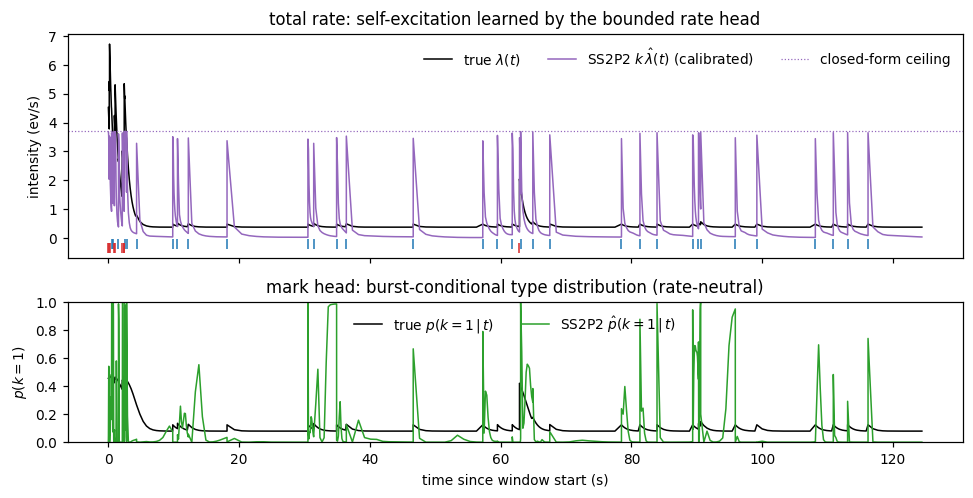

In [11]:
fig, axes = plt.subplots(2, 1, figsize=(9, 4.6), sharex=True,
                         gridspec_kw={'height_ratios': [1.6, 1]})

ax = axes[0]
ax.plot(grid_t - t0, lam_true_g.sum(1), 'k', lw=1.0, label=r'true $\lambda(t)$')
ax.plot(grid_t - t0, k_cal * lam_hat, color='tab:purple', lw=1.0,
        label=r'SS2P2 $k\,\hat\lambda(t)$ (calibrated)')
ax.axhline(k_cal * model.decoder.rate_bounds()[1], color='tab:purple', ls=':', lw=0.8,
           label='closed-form ceiling')
for k, c in [(0, 'tab:blue'), (1, 'tab:red')]:
    m = (ev_k == k) & (ev_t >= t0) & (ev_t <= t0 + WIN_T)
    ax.plot(ev_t[m] - t0, np.full(m.sum(), -0.2 - 0.15*k), '|', color=c, ms=7)
ax.set_ylabel('intensity (ev/s)'); ax.legend(ncol=3, frameon=False)
ax.set_title('total rate: self-excitation learned by the bounded rate head')

ax = axes[1]
ax.plot(grid_t - t0, lam_true_g[:, 1] / lam_true_g.sum(1), 'k', lw=1.0,
        label=r'true $p(k{=}1\,|\,t)$')
ax.plot(grid_t - t0, p_hat, color='tab:green', lw=1.0, label=r'SS2P2 $\hat p(k{=}1\,|\,t)$')
ax.set(xlabel='time since window start (s)', ylabel=r'$p(k{=}1)$', ylim=(0, 1))
ax.legend(ncol=2, frameon=False)
ax.set_title('mark head: burst-conditional type distribution (rate-neutral)')
plt.tight_layout()

In [12]:
# quantitative check on the full held-out grid
from scipy.stats import pearsonr
r_lam = pearsonr(lam_hat, lam_true_g.sum(1))[0]
r_p   = pearsonr(p_hat, lam_true_g[:, 1] / lam_true_g.sum(1))[0]
print(f"corr(lambda_hat, lambda_true) = {r_lam:.3f}")
print(f"corr(p_hat,      p_true)      = {r_p:.3f}")
# time-weighted mean rates (trapezoid over the irregular grid)
dur = grid_t[-1] - grid_t[0]
print(f"time-avg rate (held-out): true {np.trapz(lam_true_g.sum(1), grid_t)/dur:.3f}  "
      f"raw model {np.trapz(lam_hat, grid_t)/dur:.3f}  "
      f"calibrated {k_cal*np.trapz(lam_hat, grid_t)/dur:.3f} ev/s")

corr(lambda_hat, lambda_true) = 0.693
corr(p_hat,      p_true)      = 0.293
time-avg rate (held-out): true 0.495  raw model 1.489  calibrated 0.405 ev/s


## 6. What transfers to the real system

Everything above is the LOB pipeline in miniature:

| here (toy) | production (`ma_cbse`) |
|---|---|
| $K=2$ Hawkes types | 62 order-flow channels (`MO/CO/LO/IS` × side × level) |
| 64-event windows | 1024-event windows, TBPTT carried state |
| `compute_loss` on synthetic windows | same call in `training/train.py` |
| dense-grid $\hat\lambda$ readout | `_distribution_at_dts` in calibration/simulation |
| thinning on $\lambda^{\text{true}}$ | `simulate_stream` samples the **model** by inversion/thinning |

The two design invariants this notebook makes visible:

1. **The ceiling is architectural, not learned.** The dotted line
   ($s\cdot\mathrm{softplus}(c)$, `rate_bounds()`) bounds $\hat\lambda$ for *any* input —
   that's the exact dominating rate for thinning and the reason free-running rollouts
   can't diverge (compare s2p2, whose unbounded head fails calibration on 7/9 checkpoints).
2. **Marks can't destabilize the clock.** $p(k|t)$ is a softmax on the same embedding, so
   mark learning reshapes *composition* while $\sum_k \lambda_k \equiv \lambda$ stays
   pinned — the "rate-neutral" property used throughout the paper.